## Данные

Синтетические blob'ы: 1200 точек, 2 класса.

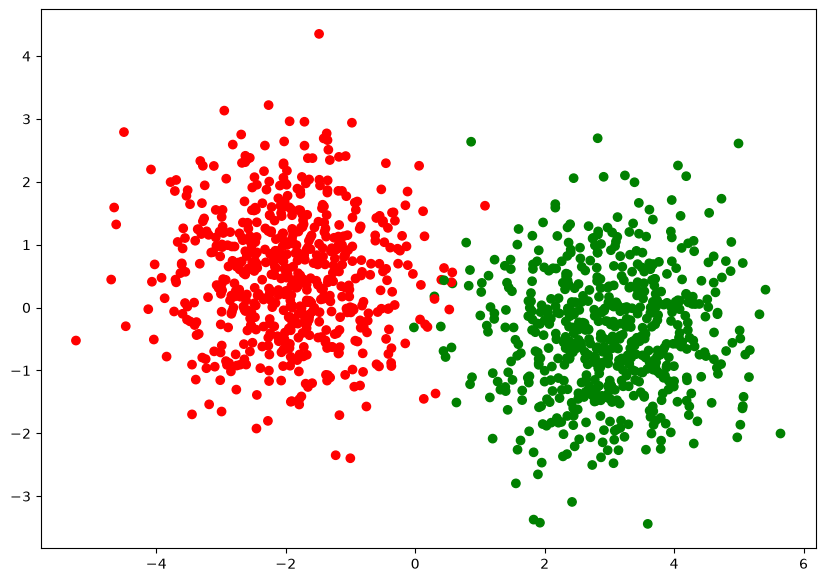

In [8]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=1200, centers=[[-2, 0.5], [3, -0.5]], cluster_std=1, random_state=42)

colors = ('red', 'green')
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

## Подготовка данных

Сплит 1000/200. Признаки — float32; `y` превращён в столбец `view(-1, 1)` — так нужно для `BCELoss`.

In [9]:
from sklearn.model_selection import train_test_split
import torch

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

## Архитектура

Linear(2→2) → ReLU → Linear(2→1) → Sigmoid. На выходе — вероятность класса (0..1).

In [10]:
import torch.nn as nn

class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()

        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)

        return x

model = MyNet()
        

In [11]:
import torch
train_ld = torch.utils.data.DataLoader(list(zip(X_train, y_train)), batch_size=64, shuffle=True)
test_ld = torch.utils.data.DataLoader(list(zip(X_test, y_test)), batch_size=64, shuffle=False)

## Loss и оптимизатор

`BCELoss` (бинарная кросс-энтропия) + Adam (lr=0.001).

In [12]:
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Цикл обучения

Стандартный цикл: forward → loss → backward → step → zero_grad. `tqdm` показывает прогресс по эпохам.

In [17]:
import tqdm 
from tqdm.auto import tqdm

def train(model, loader, criterion, optimizer, num_epochs):
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = []

        for X_batch, y_batch in loader:
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)
            epoch_loss.append(loss.item())

            loss.backward()

            optimizer.step()

            optimizer.zero_grad()

        print(f'Эпоха {epoch}, loss = {np.mean(epoch_loss)}')

    return model

## Обучение

In [21]:
model = train(model, train_ld, loss_fn, optimizer, 50)

 52%|█████▏    | 26/50 [00:00<00:00, 129.07it/s]

Эпоха 0, loss = 0.12011591531336308
Эпоха 1, loss = 0.11964205838739872
Эпоха 2, loss = 0.11750595178455114
Эпоха 3, loss = 0.11776267178356647
Эпоха 4, loss = 0.11597338179126382
Эпоха 5, loss = 0.1158437835983932
Эпоха 6, loss = 0.11508022714406252
Эпоха 7, loss = 0.11323445802554488
Эпоха 8, loss = 0.11304833646863699
Эпоха 9, loss = 0.11175695713609457
Эпоха 10, loss = 0.11103010782971978
Эпоха 11, loss = 0.10968519747257233
Эпоха 12, loss = 0.10937023814767599
Эпоха 13, loss = 0.10774675570428371
Эпоха 14, loss = 0.10883918916806579
Эпоха 15, loss = 0.10640640975907445
Эпоха 16, loss = 0.10655827634036541
Эпоха 17, loss = 0.10535363480448723
Эпоха 18, loss = 0.1040899152867496
Эпоха 19, loss = 0.10300878761336207
Эпоха 20, loss = 0.10291504207998514
Эпоха 21, loss = 0.10235351789742708
Эпоха 22, loss = 0.10176915815100074
Эпоха 23, loss = 0.09976893709972501
Эпоха 24, loss = 0.099493776448071
Эпоха 25, loss = 0.0992906647734344
Эпоха 26, loss = 0.09785991488024592
Эпоха 27, loss =

100%|██████████| 50/50 [00:00<00:00, 127.71it/s]

Эпоха 28, loss = 0.09649220621213317
Эпоха 29, loss = 0.09592794813215733
Эпоха 30, loss = 0.09514431050047278
Эпоха 31, loss = 0.09470863500609994
Эпоха 32, loss = 0.0938293831422925
Эпоха 33, loss = 0.09319494292140007
Эпоха 34, loss = 0.09319255407899618
Эпоха 35, loss = 0.09196897642686963
Эпоха 36, loss = 0.09102899022400379
Эпоха 37, loss = 0.09076495422050357
Эпоха 38, loss = 0.09000547742471099
Эпоха 39, loss = 0.08925147633999586
Эпоха 40, loss = 0.08808145206421614
Эпоха 41, loss = 0.0877441456541419
Эпоха 42, loss = 0.0872896071523428
Эпоха 43, loss = 0.08644139673560858
Эпоха 44, loss = 0.08601292595267296
Эпоха 45, loss = 0.0848815836943686
Эпоха 46, loss = 0.08480014419183135
Эпоха 47, loss = 0.08397643314674497
Эпоха 48, loss = 0.0837274044752121
Эпоха 49, loss = 0.08326436067000031


## Результаты

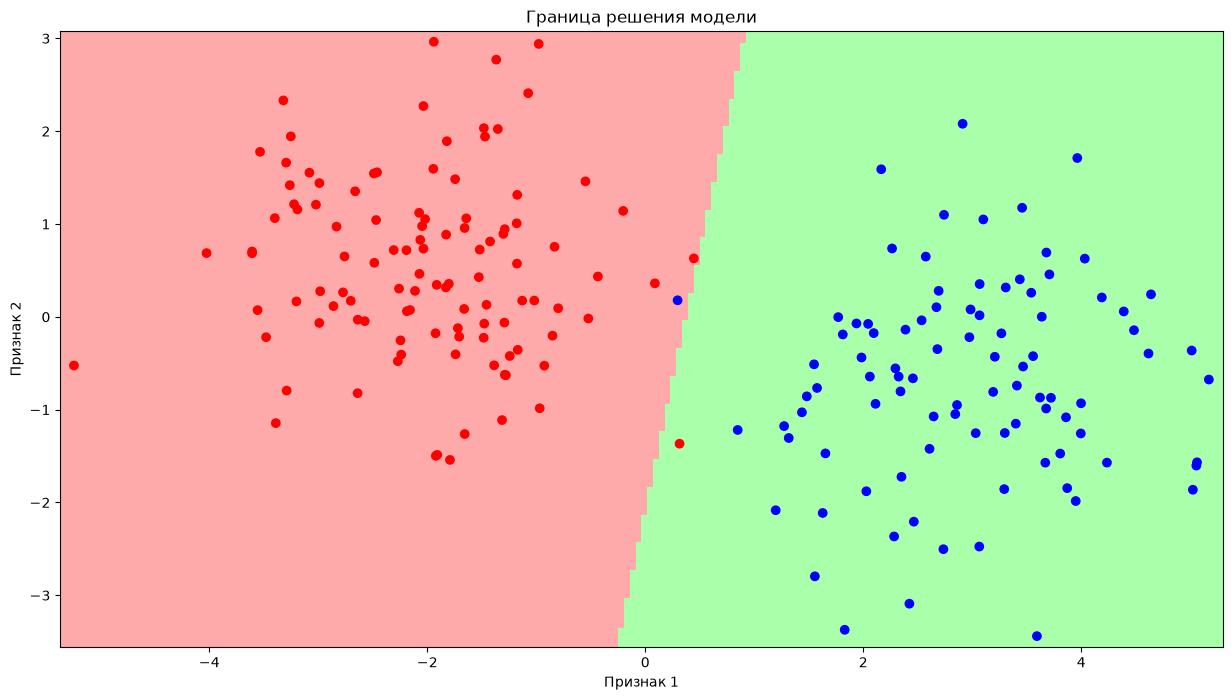

In [23]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_test_np = X_test.detach().cpu().numpy()
y_test_np = y_test.detach().cpu().numpy()

plt.figure(figsize=(15, 8))

eps = 0.1
xx, yy = np.meshgrid(
    np.linspace(np.min(X_test_np[:, 0]) - eps, np.max(X_test_np[:, 0]) + eps, 200),
    np.linspace(np.min(X_test_np[:, 1]) - eps, np.max(X_test_np[:, 1]) + eps, 200)
)

with torch.no_grad():
    Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))

Z = Z.reshape(xx.shape).detach().numpy()
Z = (Z > 0.5).astype(int)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

colors = ['red', 'blue']
colored_y = np.zeros(y_test_np.size, dtype=str)
for i, cl in enumerate([0, 1]):
    colored_y[y_test_np.ravel() == cl] = str(colors[i])

plt.scatter(X_test_np[:, 0], X_test_np[:, 1], c=colored_y)

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Граница решения модели')
plt.show()